# Introduction

This project is meant to serve as an in-depth analysis of the artist Coldplay's discography. Coldplay are one of today's most popular bands in many countries around the world and have sold over 100 million albums. Therefore, it is only thought-provoking what makes this world-renowned band who they are. 

To start, their evolution will be analyzed, including their gradual transition away from rock and towards pop-oriented music. Then, an important question will be investigated: what exactly makes their hit songs popular compared to their less popular songs? Various audio features will be considered. Finally, Coldplay have amassed a large discography throughout almost two decades (up to their ninth studio album) of music making. This music is fairly diverse and covers many different styles; does the data show this?

The dataset used was taken from the following site: https://www.kaggle.com/datasets/faizalkarim/coldplay-albums-and-live-shows. The website also includes descriptions of each feature in the dataset. It includes a comprehensive set of their studio albums (except *Moon Music*, as the dataset is from 2023) and live albums. The dataset originates from data collected by Spotify, which includes many different features for each song, including the album name, popularity, duration, tempo, and many others.

# Data Cleaning

First, the proper Python libraries will be imported, including pandas for data manipulation, matplotlib and seaborn for visualization, and numpy and scipy for various mathematical and statistical uses. The data is then imported from the csv file.

In [698]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/coldplay.csv")

Before investigating the data, the datatypes are checked to see if they fit analysis needs.

In [699]:
df.dtypes

name                    str
duration            float64
release_date            str
album_name              str
explicit               bool
popularity            int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
dtype: object

Two problems stand out. Firstly, time_signature should be a string and not numeric, since time signatures are better interpreted as categories of numbers of beats rather than true numbers. It's also more informative to display the full time signature rather than just the number of beats, for example 3 -> 3/4.

In [700]:
df["time_signature"] = df["time_signature"].astype(str) + "/4"

df["time_signature"].head()

0    4/4
1    4/4
2    4/4
3    4/4
4    4/4
Name: time_signature, dtype: str

The other problem is that release_date should be a datetime to allow for plotting on line charts. 

In [701]:
df["release_date"] = pd.to_datetime(df["release_date"])

df["release_date"].head()

0   2021-10-15
1   2021-10-15
2   2021-10-15
3   2021-10-15
4   2021-10-15
Name: release_date, dtype: datetime64[us]

Other issues are the scales of popularity and duration. Popularity has values on a scale between 0 and 100, but many other numeric features are between 0.0 and 1.0. To keep it consistent with the other features, it will be rescaled to between 0.0 and 1.0. Additionally, duration is in seconds, but most people consider song duration in minutes.

In [702]:
df["popularity"] = df["popularity"] / 100
df["duration"] = df["duration"] / 60

df[["popularity", "duration"]].describe()

,popularity,duration
count,232.000000,232.000000
mean,0.433621,4.371043
std,0.211158,1.514758
min,0.000000,0.356467
25%,0.230000,3.753050
50%,0.440000,4.362883
75%,0.590000,5.054325
max,0.910000,10.284283


Next, possible whitespaces are stripped to avoid potential slight variations in data values such as "Ghost Stories" and " Ghost Stories".

In [703]:
str_cols = df.select_dtypes(include=str).columns

df[str_cols] = df[str_cols].apply(lambda x: x.str.strip(), axis=0)

In [704]:
df["album_name"].unique()

<StringArray>
[                     'Music Of The Spheres',
                             'Everyday Life',
                      'Live in Buenos Aires',
                             'Love in Tokyo',
                     'A Head Full of Dreams',
        'A Head Full of Dreams Tour Edition',
                   'Ghost Stories Live 2014',
                             'Ghost Stories',
                                 'Live 2012',
                               'Mylo Xyloto',
             'LeftRightLeftRightLeft (Live)',
   'Viva La Vida (Prospekt's March Edition)',
 'Viva La Vida or Death and All His Friends',
                                       'X&Y',
                                 'Live 2003',
               'A Rush of Blood to the Head',
                                'Parachutes']
Length: 17, dtype: str

As shown above, the dataset contains live performances as well as the studio albums. Since live performances differ very little from the studio variants, they will be removed to avoid song duplicates. Again, *Moon Music* won't be included, since the data dates to 2023 and the album only released a year later.

In [705]:
df = df[df["album_name"].isin(['Music Of The Spheres',
                               'Everyday Life',
                               'A Head Full of Dreams',
                               'Ghost Stories',
                               'Mylo Xyloto',
                               'Viva La Vida or Death and All His Friends',
                               'X&Y',
                               'A Rush of Blood to the Head',
                               'Parachutes'])]

df["album_name"].unique()

<StringArray>
[                     'Music Of The Spheres',
                             'Everyday Life',
                     'A Head Full of Dreams',
                             'Ghost Stories',
                               'Mylo Xyloto',
 'Viva La Vida or Death and All His Friends',
                                       'X&Y',
               'A Rush of Blood to the Head',
                                'Parachutes']
Length: 9, dtype: str

Now let's check for duplicates across all columns and also specifically for the name column, since there shouldn't be duplicate song names.

In [706]:
print(df.duplicated().any())
print(df.duplicated(["name"]).any())

False
False


None can be found. Now let's check for possible missing values and empty strings.

In [707]:
print(df.isna().any(axis=1).any(axis=0))

False


In [708]:
df.apply(lambda x: x == "", axis=1).any(axis=0)

name                False
duration            False
release_date        False
album_name          False
explicit            False
popularity          False
acousticness        False
danceability        False
energy              False
instrumentalness    False
liveness            False
loudness            False
speechiness         False
tempo               False
time_signature      False
valence             False
dtype: bool

Again, none found. 

The indices no longer align with the length of the DataFrame, so it will be reindexed.

In [709]:
df.reset_index(drop=True, inplace=True)

One may notice that there are strange emojis present in the name column. These are stylistic depictions of songs in the album *Music of the Spheres*.

In [710]:
df["name"].sort_values(ascending=False).head(10)

0            🪐
8            🌎
5           ❤️
3            ✨
10           ♾
25     بنی آدم
22         Èkó
72         Yes
106     Yellow
83         X&Y
Name: name, dtype: str

The actual names of the songs would be more helpful, so they will be individually replaced.

In [711]:
df.loc[[0, 8, 5, 3, 10, 25], "name"] = ["Music of the Spheres", "Music of the Spheres II", "Human Heart", "Alien Choir", 
                                        "Infinity Sign", "Bani Adam"]

In [712]:
df.loc[df["album_name"] == "Music Of The Spheres", "name"]

0        Music of the Spheres
1                Higher Power
2                   Humankind
3                 Alien Choir
4             Let Somebody Go
5                 Human Heart
6         People of The Pride
7                    Biutyful
8     Music of the Spheres II
9                 My Universe
10              Infinity Sign
11                 Coloratura
Name: name, dtype: str

The album name "Viva La Vida or Death and All His Friends" will be shortened to "Viva La Vida" so that it won't extend graph image heights farther than necessary. Additionally, people often refer to the album simply as "Viva La Vida" anyway.

In [713]:
df.loc[df["album_name"] == "Viva La Vida or Death and All His Friends", "album_name"] = "Viva La Vida"

df["album_name"].unique()

<StringArray>
[       'Music Of The Spheres',               'Everyday Life',
       'A Head Full of Dreams',               'Ghost Stories',
                 'Mylo Xyloto',                'Viva La Vida',
                         'X&Y', 'A Rush of Blood to the Head',
                  'Parachutes']
Length: 9, dtype: str

Now the values of the columns will be checked for any invalid data. The following columns should only have values between 0.0 and 1.0.

In [714]:
features = ['popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'valence']

print("Feature minimums:\n", df[features].min(), "\n")
print("Feature maximums:\n", df[features].max())

Feature minimums:
 popularity          0.000000
acousticness        0.000114
danceability        0.085900
energy              0.049100
instrumentalness    0.000000
liveness            0.035900
speechiness         0.024300
valence             0.018500
dtype: float64 

Feature maximums:
 popularity          0.910
acousticness        0.970
danceability        0.738
energy              0.924
instrumentalness    0.990
liveness            0.980
speechiness         0.248
valence             0.802
dtype: float64


The other features are graphed to visuzlize their distributions and see if they're in order. Each bar of the histogram shows the number of songs in that bar.

In [715]:
# Visual styling
sns.set_style("dark")
sns.set_palette("muted")
plt.rcParams['font.family'] = 'serif'

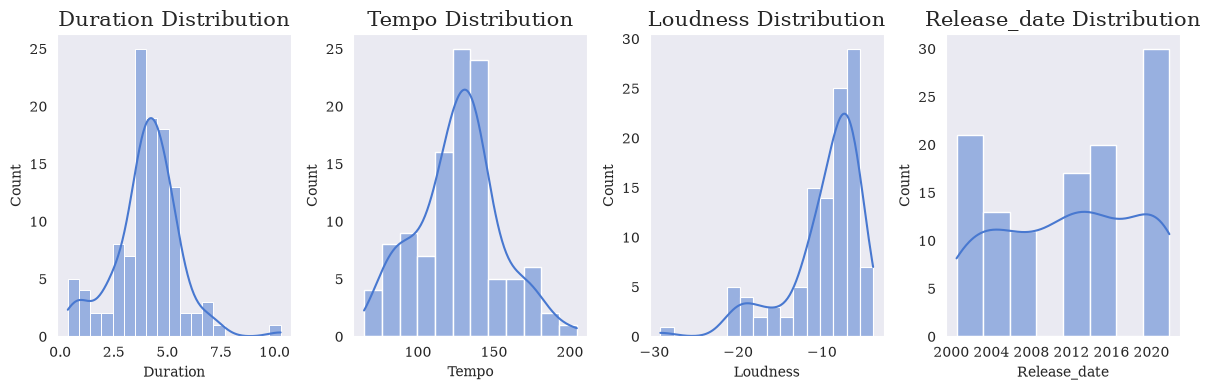

In [716]:
# Features to investigate
features = ["duration", "tempo", "loudness", "release_date"]

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes = axes.flatten()

# Generate graphs
for ax, feature in zip(axes, features):
    sns.histplot(x=feature, data=df, kde=True, ax=ax)
    ax.set_xlabel(feature.capitalize())
    ax.set_title(feature.capitalize() + " Distribution", fontsize=15)

plt.tight_layout()
plt.show()

Everything seems to fit expectations. Perhaps something initially suspicious is that there's a song around 600 seconds (ten minutes) long, however the song Coloratura is actually that long and thus it's not a mistake.

The fully cleaned data will be saved into a seperate file.

In [717]:
df.to_csv("../data/processed/coldplay_cleaned.csv", index=False)

# Coldplay's Evolution

Coldplay has amassed a diverse discography over the years spanning both rock and pop music. In particular, Coldplay is known for having transitioned from acoustic rock music in their earlier studio albums gradually to pop music in the modern-day. Therefore, I would expect their music to become less acoustic, more engertic, and greater in tempo.

Firstly, their first two albums are considered acoustic rock, while the albums later started to use more electronic instrumentation that is characteristic of pop.

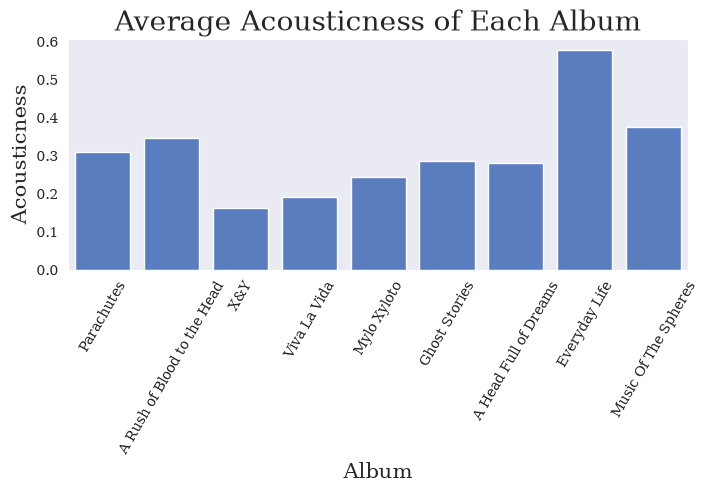

In [718]:
df = df.sort_values(by=["release_date"])

fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(x="album_name", y="acousticness", data=df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Acousticness", fontsize=15)
ax.set_title("Average Acousticness of Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

Interestingly, the first two albums were the most acoustic all the way until *Everyday Life*, which became by far the most acoustic album, with *Music Of The Spheres* also being more acoustic. This suggests that Coldplay did indeed become less acoustic after *A Rush of Blood to the Head*, only to become acoustic again much later. Interestingly, *Music Of The Spheres* is considered to be pop/pop rock, so their pop music doesn't necessarily have to be unacoustic.

In addition to being less acoustic, pop is generally more energetic than acoustic rock, so perhaps the energy level increased.

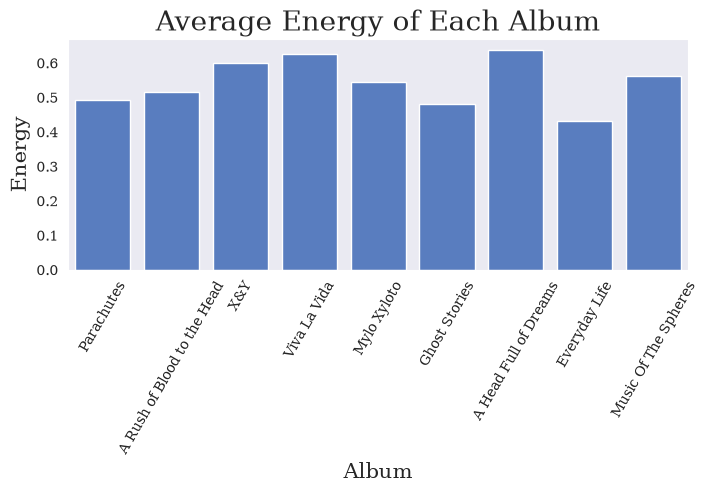

In [719]:
fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(x="album_name", y="energy", data=df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Energy", fontsize=15)
ax.set_title("Average Energy of Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

This roughly lines up with expectations, with energy generally trending upward. Although *Ghost Stories* and *Everyday Life* are exceptions, as they were made with the intention of being more mellow and not like traditional pop. Of course, all albums have exceptions within themselves and can have wide ranges in energy, as shown below (to see the boxplots for all the albums, see Figure 1 in the Appendix at the end of the notebook).

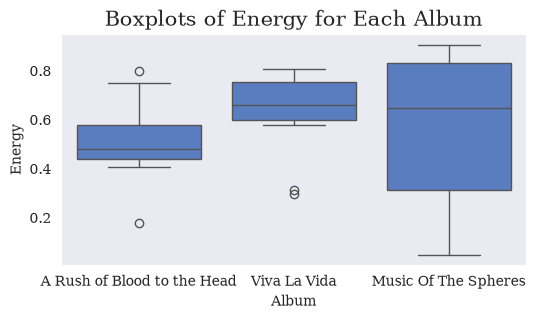

In [720]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.boxplot(x="album_name", y="energy", 
            data=df.query("album_name.isin(['Viva La Vida', 'A Rush of Blood to the Head', 'Music Of The Spheres'])"))
ax.set_xlabel("Album")
ax.set_ylabel("Energy")
ax.set_title("Boxplots of Energy for Each Album", fontsize=15)

plt.show()

Albums typically considered to be energetic, such as *Viva La Vida*, have mellow tracks that act as outliers, such as "Death And All His Friends". Similarily in *A Rush of Blood to the Head*, "Clocks" is significantly more energetic than most of the other songs in the album. Moreover, *Music Of The Spheres* has a very wide range of energy, despite being relatively energetic on average. This shows that typcal album associations don't always hold for each indivdual song.

Finally, one would assume that an increase in energy would mean faster music and therefore a greater tempo.

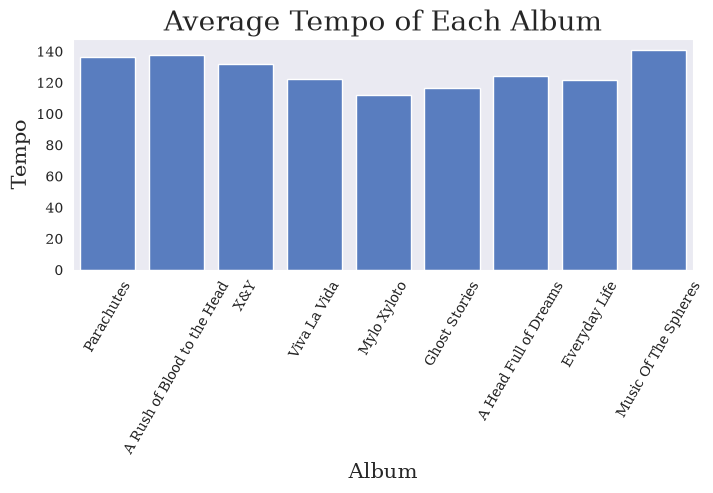

In [721]:
fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(x="album_name", y="tempo", data=df, errorbar=('ci', False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Tempo", fontsize=15)
ax.set_title("Average Tempo of Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

However the data seems to suggest the opposite. Tempo seemed to decrease with time, with the exception of *Music Of The Spheres*. Ironically, *Parachutes* and *A Rush of Blood to the Head*, some of their least energetic albums, have some of the fastest average tempos. This suggests that Spotify's energy metric captures aspects of a song beyond speed, such as loudness and production style. This can be seen when tempo and energy are compared directly.

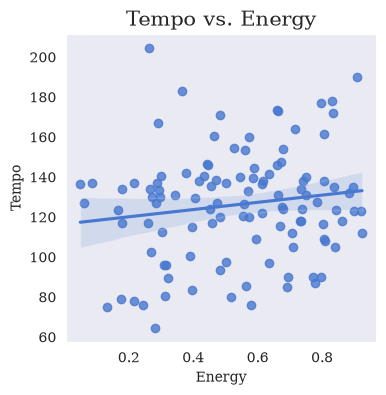

In [722]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.regplot(x="energy", y="tempo", data=df)
ax.set_xlabel("Energy")
ax.set_ylabel("Tempo")
ax.set_title("Tempo vs. Energy", fontsize=15)

plt.show()

There seems to be no significant relationship between the two, further proving that high energy in Coldplay's music isn't dependant on high tempo. Let's see if the increase in energy is instead due to greater volume, taking into account the ranges for each album.

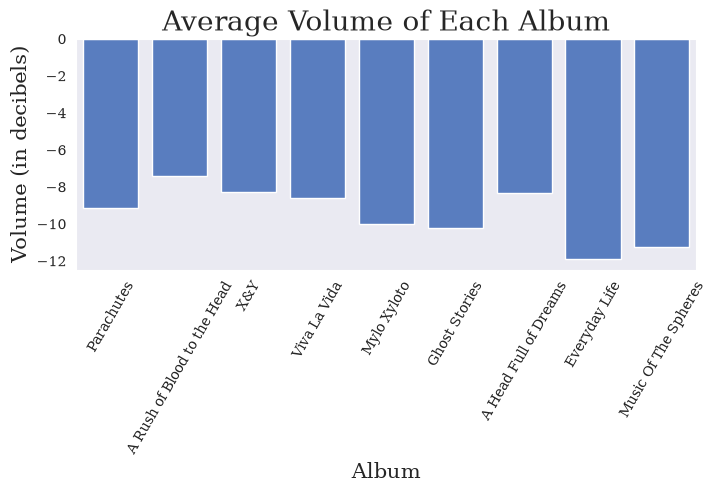

In [723]:
fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(x="album_name", y="loudness", data=df, errorbar=("ci", False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Volume (in decibels)", fontsize=15)
ax.set_title("Average Volume of Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

However on average, volume don't seem to be consistently increasing and, if anything, is decreasing. Even albums with relatively high volume levels have extreme outliers that are much quieter. There must be some other factor that plays into energy that, unfortunately, Spotify doesn't specify.

To conclude, many insights can be drawn regarding Coldplay's evolution. Generally speaking, their music became less acoustic, more energetic, and less fast and stayed relatively consistent in volume. However, albums like *Ghost Stories* and *Everyday Life* defy some of these trends. Therefore, Coldplay's evolution can't be accurately summarized as simply following certain trends without acknowledging that their experimentation and genre-blending leads to much of their music defying certain assumptions.

# Coldplay Music Popularity

As seen, trends can be found in Coldplay's music through time. But an equally as interesting topic: what makes their hit songs as popular as they are? Are there trends that can be uncovered?

Below is the correlation each numeric feature has with popularity from -1.0 (perfectly negatively correlated) and 1.0 (perfectly positively correlated), with 0.0 meaning they are uncorrelated. 

In [724]:
df.corr(method="spearman", numeric_only=True)["popularity"]

duration            0.252075
explicit           -0.165986
popularity          1.000000
acousticness       -0.204117
danceability        0.297324
energy              0.166519
instrumentalness   -0.429745
liveness           -0.183960
loudness            0.340800
speechiness        -0.259655
tempo               0.143321
valence            -0.011878
Name: popularity, dtype: float64

Interestingly, there are no strong relationships with popularity, neither positive nor negative. This suggests that Coldplay song popularity is relatively unpredicteable. However, perhaps some non-monotonic relationships are indeed present that spearmen correlation can't capture well. Loudness and valence are shown as examples (see Figure 2 in the Appendex to see equvalent plots for all numeric features).

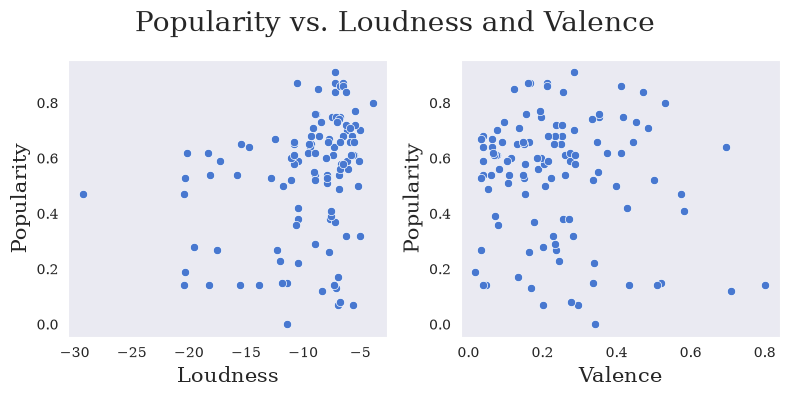

In [725]:
features = ["loudness", "valence"]

# Create a grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()

# Iterating through and displaying both features
for ax, feature in zip(axes, features):
    sns.scatterplot(x=feature, y='popularity', data=df, ax=ax)
    ax.set_ylabel('Popularity', fontsize=15)
    ax.set_xlabel(feature.capitalize(), fontsize=15)

# Add figure title
fig.suptitle("Popularity vs. Loudness and Valence", fontsize=20)

plt.tight_layout()
plt.show()

This also doesn't appear to be the case. No clear relationships can be discovered from either plot. This suggests that popularity is influenced by a combination of factors beyond Spotify's audio descriptors. Some possibilities include release strategy, cultural impact, and exposure.

But perhaps some of their studio albums are more popular than others. Many prefer their earlier albums over their modern music.

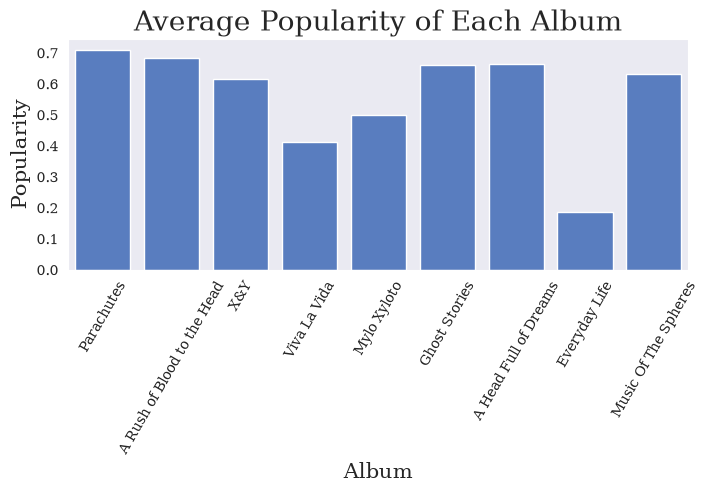

In [726]:
fig, ax = plt.subplots(figsize=(8, 3))

sns.barplot(x="album_name", y="popularity", data=df, errorbar=("ci", False))
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Popularity", fontsize=15)
ax.set_title("Average Popularity of Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

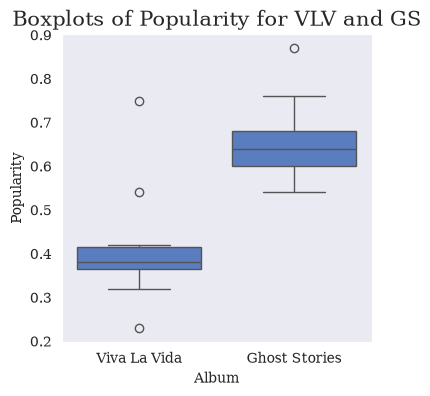

In [727]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(x="album_name", y="popularity", 
            data=df.query("album_name.isin(['Viva La Vida', 'Ghost Stories'])"))
ax.set_xlabel("Album")
ax.set_ylabel("Popularity")
ax.set_title("Boxplots of Popularity for VLV and GS", fontsize=15)

plt.show()

Some interesting insights can be drawn:
* Their first two albums are indeed their most popular ones, albeit not by a significant amount.
* Some albums, especially *Everyday Life*, have significantly lower average scores than the others. This aligns with many unpopular opinions regarding Coldplay's eighth album.
* Many strong outliers exist according to the box plots (see Figure 3 in the Appendix for box plots for each album). For example, despite *Viva La Vida* ranking lower than the others overall, two songs strongly outperform the rest of the album. This is sometimes the case in music; one or a few songs can be significantly more popular than the rest of the album.

All of these results underscore how diverse Coldplay's music is and how many styles they have tried over the years. No one style seems to draw fans' attention more than others and predicting popularity is clearly more complicated than simply anlyzing music's audio characteristics.

# Feature Variance and Relationships

I have been mentioning Coldplay's diversity, both in the context of their evolution through time and of the popularity of their music. But just how diverse does Coldplay get? Which characteristics are more varied and which tend to be more consistent? What relationships might some have with one another?

There are many key metrics to analyze. Firstly, the feature just analyzed: popularity. Their albums have strong differences in popularity, but what about their indiviudal songs? The below histogram measures the percentage each bar takes up in the data.

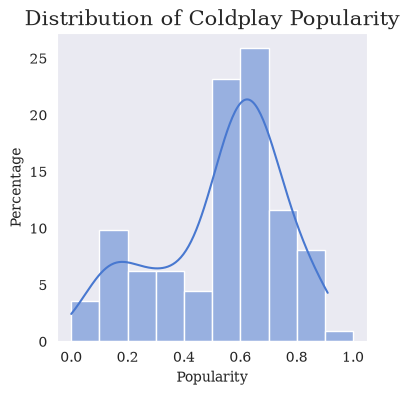

In [728]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.histplot(x="popularity", stat="percent", bins=10, binrange=(0.0, 1.0), kde=True, data=df)
ax.set_xlabel("Popularity")
ax.set_ylabel("Percentage")
ax.set_title("Distribution of Coldplay Popularity", fontsize=15)

plt.show()

Coldplay seems to be reasonably popular, with around 50% of their music being between 0.5 and 0.7. A good portion of their music is between 0.1 and 0.4, however. This is likely made up in majority by those less popular albums found before.

Coldplay is also known for having generally happy and positive music, and usually don't stray into sad melodies. One would therefore expect the majority of their music to sit around high valence values.

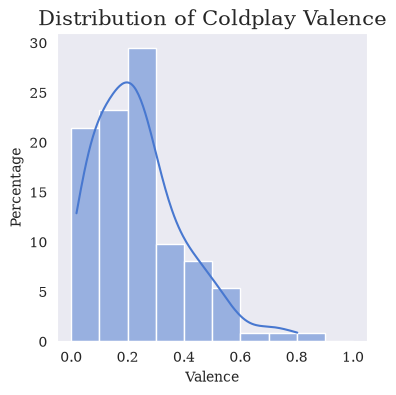

In [729]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.histplot(x="valence", stat="percent", bins=10, binrange=(0.0, 1.0), kde=True, data=df)
ax.set_xlabel("Valence")
ax.set_ylabel("Percentage")
ax.set_title("Distribution of Coldplay Valence", fontsize=15)

plt.show()

Very strangely, the exact opposite seems to be the case. This doesn't appear to make sense, however Spotify's valence characteristic could be a complex measure describing a variety of features of the music. Some attributes included might be:
* major vs. minor tonality
* harmony
* chord progressions
* timbre
* melodic contour
* rhythmic characteristics

It's especially complicated with Coldplay, an artist that has experimented with many styles, often does genre-mixing, and can have emotionally complex lyrics. That said, it is worth looking into possible correlations with the other features (once again, values are from -1.0 to 1.0).

In [730]:
df.corr(method="spearman", numeric_only=True)["valence"]

duration           -0.195676
explicit            0.051342
popularity         -0.011878
acousticness       -0.211082
danceability        0.466918
energy              0.277823
instrumentalness   -0.138679
liveness            0.091043
loudness            0.210022
speechiness         0.187370
tempo              -0.194543
valence             1.000000
Name: valence, dtype: float64

Similarly to popularity, no strong relationships exist between valence and the other features (see Figure 4 in the Appendix showing scatter plots between valence and the other features). However, there is a moderate positive relationship with danceability.

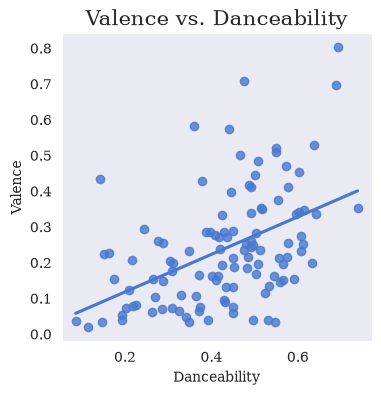

In [731]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.regplot(x="danceability", y="valence", data=df, ci=False)
ax.set_xlabel("Danceability")
ax.set_ylabel("Valence")
ax.set_title("Valence vs. Danceability", fontsize=15)

plt.show()

This makes sense, as usually the kind of music that people like to dance to is upbeat and positive.

Since Coldplay has experimented with different genres, one would expect there to be wide variety in the speed and intensity of their music. That warrents investigating danceability, loudness, energy, and tempo. Danceability and energy have values on a scale of 0.0 to 1.0; loudness is measured in decibels (db) and tempo in beats per minute (bpm). The below table shows the correlation coefficients between the feature of each row and column.

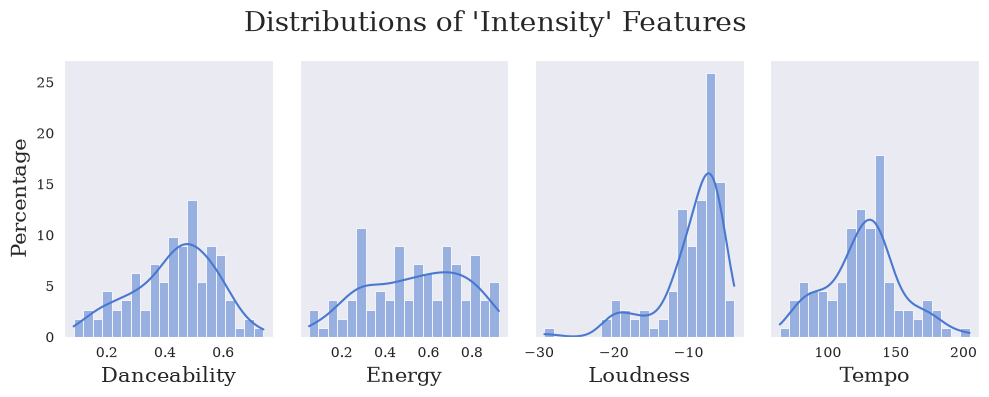

In [732]:
# Features to investigate
features = ["danceability", "energy", "loudness", "tempo"]

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(10, 4), sharey=True)
axes = axes.flatten()

# Create charts
for feature, ax in zip(features, axes):
    sns.histplot(x=feature, stat="percent", data=df, bins=20, kde=True, ax=ax)
    ax.set_xlabel(feature.capitalize(), fontsize=15)
    ax.set_ylabel("Percentage", fontsize=15)

# Add figure title
fig.suptitle("Distributions of 'Intensity' Features", fontsize=20)

plt.tight_layout()
plt.show()

In [733]:
features = ["danceability", "energy", "loudness", "tempo"]

df[features].corr(method="spearman")

,danceability,energy,loudness,tempo
danceability,1.000000,0.124770,0.137234,-0.113815
energy,0.124770,1.000000,0.753249,0.096377
loudness,0.137234,0.753249,1.000000,0.070446
tempo,-0.113815,0.096377,0.070446,1.000000


This is roughly the case, as, indeed, the values cover a wide range. However, there are some centers for each feature: danceability around 0.5, loudness around -8 decibels, and tempo around 130 bpm. Overall, this suggest that their music tends to be relatively loud (typical decibel values are between -60 and 0) and fast (130 is characterized as allegro, or fast). 

However, energy and danceability show more variety. This would suggest that there could be many loud and fast songs that aren't necessarily energetic or "danceable". And, as expected, no strong relationships are present with danceability and the others. This implies that it's possible for a danceable song to be fast or slow, for example. However, energy and loudness are strongly correlated. So energetic music is actually often loud and unenergetic music is often relatively quiet. This suggests that the songs in the "peak" in the loudness histogram are likely all concentrated in the right side of the energy histogram, and the quieter songs are more concentrated on the left side of the energy histogram. 

Interestingly though, there's no strong relationship between tempo and loudness. One would expect loud music to be faster, but this is apparently not the case. This fits songs that are loud, but not fast, such as "Adventure of a Lifetime" from *A Head Full of Dreams*.

Lastly, what is the average duration of Coldplay's music? Coldplay tends to make longer songs over 4 minutes long, so likely the peak of the histogram will be there.

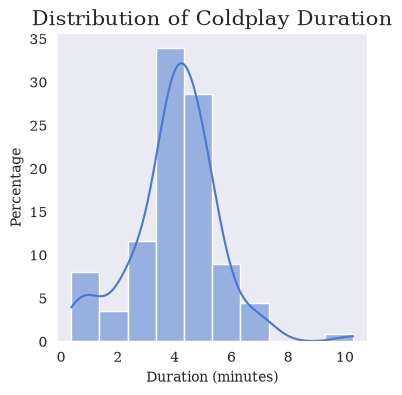

In [734]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.histplot(x="duration", stat="percent", bins=10, kde=True, data=df)
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Percentage")
ax.set_title("Distribution of Coldplay Duration", fontsize=15)

plt.show()

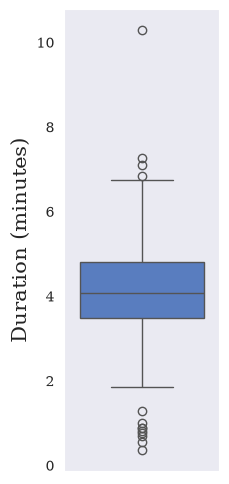

In [735]:
fig, ax = plt.subplots(figsize=(2, 6))

sns.boxplot(y="duration", data=df)
ax.set_ylabel("Duration (minutes)", fontsize=15)

plt.show()

In [736]:
print("Percent of songs between 3 and 5 minutes long: ", round(len(df.query("duration >= 3 & duration <= 5")) / len(df) * 100, 2))

Percent of songs between 3 and 5 minutes long:  61.61


As expected, the majority of Coldplay's music is around 4 minutes long. Over 60% of the soundtrack is within a minute from 4 minutes. As expected, there are many outliers, including by far the longest song in their discography: "Coloratura" from *Music Of The Spheres*.

This analysis underscores how varied, yet also consistent Coldplay can be. Their popularity is usually moderate, their loudness usually relatively high, their tempo often high, and their duration around 4 minutes. However, energy and danceability are more varied.

# Conclusions

Many insights can be drawn from this analysis and which answer our previous questions:
* How did Coldplay evolve? Their music gradually drifted away from acoustic rock and towards pop, and this shows in the features of their music. 
* What charcterizes their popular and unpopular music? Interestingly, nothing in particular other than that their early albums are slightly more popular on average.
* How diverse is Coldplay? Some features are relatively diverse, such as energy, while others are fairly consistent, such as song duration.

However, perhaps the single most important insight that can be gathered is that Coldplay don't perfectly fit any of these trends. Coldplay are a band that don't try to settle into one particular style or one particular feature of their music. Prominent exceptions and outliers exist for all of these insights, whether it be *Everyday Life* being highly acoustic despite being one of their later albums, or whether it be tempo generally being high, yet slow songs such as "Oceans" from *Ghost Stories* existing as well. Coldplay cannot be grouped under one simple category or given one catch-all label, and they likely don't want to be either. After all, that's what truly makes Coldplay Coldplay.

# Appendix

### Figure 1

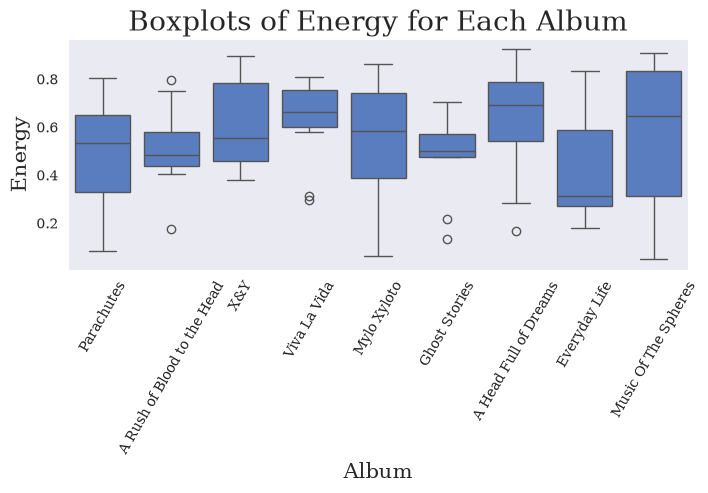

In [737]:
fig, ax = plt.subplots(figsize=(8, 3))

sns.boxplot(x="album_name", y="energy", data=df)
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Energy", fontsize=15)
ax.set_title("Boxplots of Energy for Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

### Figure 2

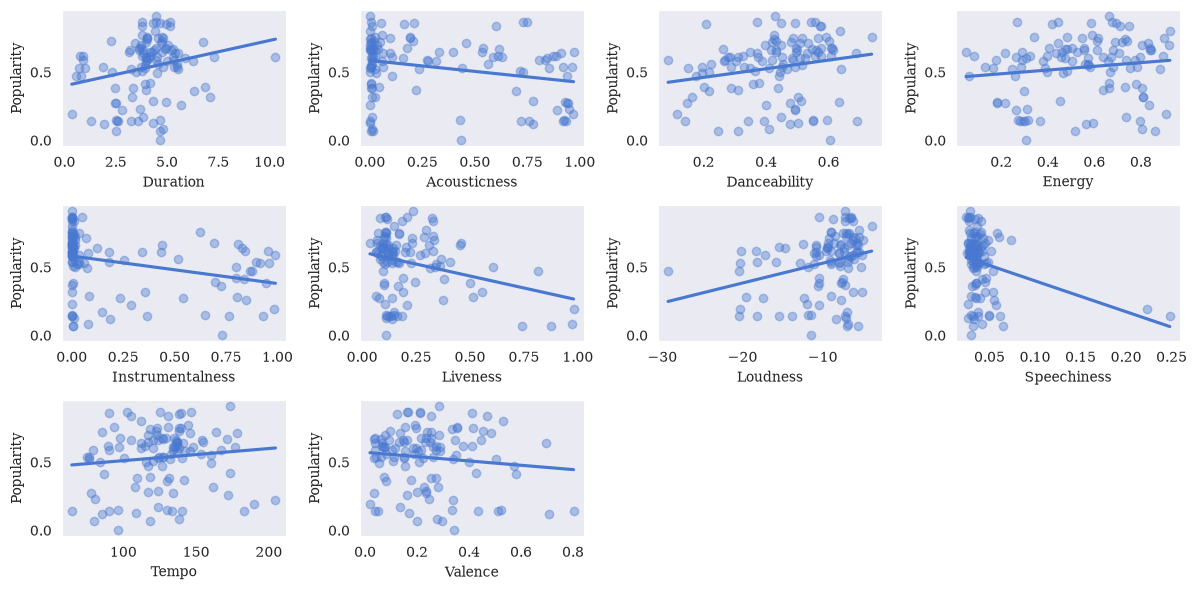

In [738]:
# Numeric columns excluding popularity itself
features = [col for col in df.select_dtypes(include='number').columns if col != 'popularity']

# Create a grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(12, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.regplot(x=feature, y='popularity', data=df, scatter_kws={"alpha": 0.4}, ci=False, ax=ax)
    ax.set_ylabel('Popularity')
    ax.set_xlabel(feature.capitalize())

# Remove any unused subplots
for ax in axes[len(features):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Figure 3

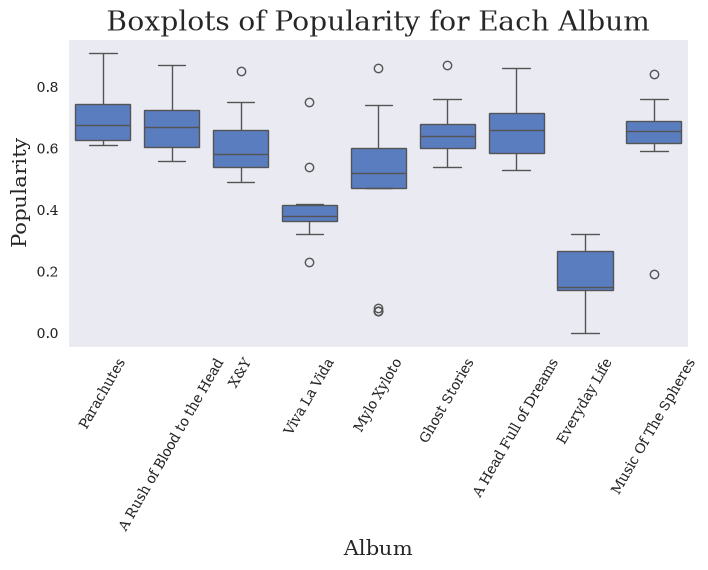

In [739]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x="album_name", y="popularity", data=df)
ax.set_xlabel("Album", fontsize=15)
ax.set_ylabel("Popularity", fontsize=15)
ax.set_title("Boxplots of Popularity for Each Album", fontsize=20)
plt.xticks(rotation=60)

plt.show()

### Figure 4

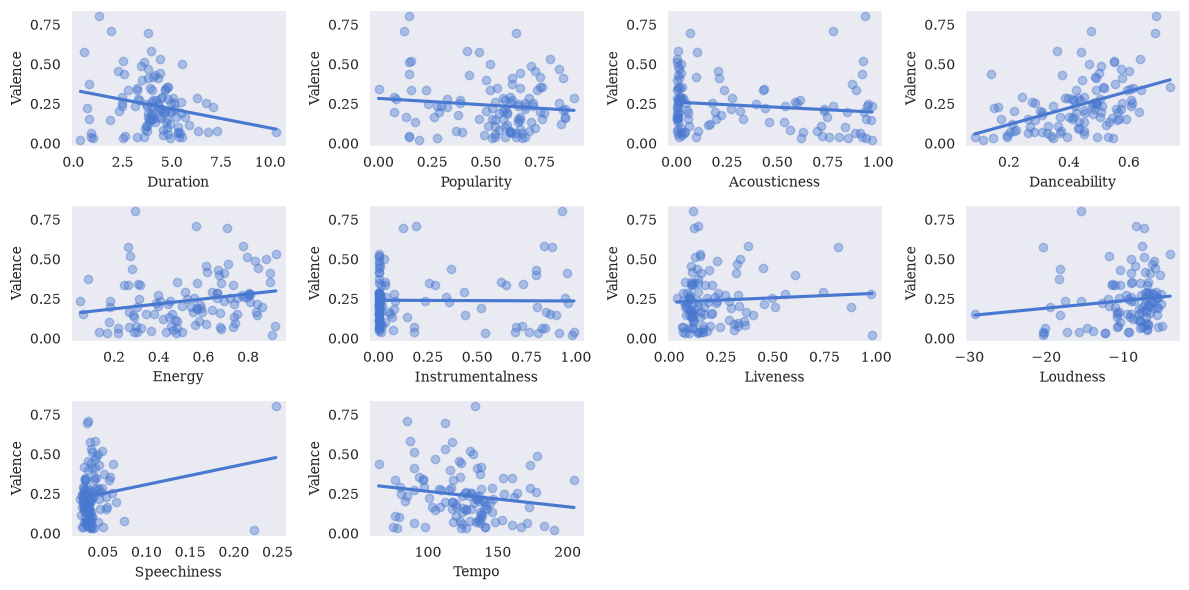

In [740]:
# Numeric columns excluding valence itself
features = [col for col in df.select_dtypes(include='number').columns if col != 'valence']

# Create a grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(12, 6))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.regplot(x=feature, y='valence', data=df, scatter_kws={"alpha": 0.4}, ci=False, ax=ax)
    ax.set_ylabel('Valence')
    ax.set_xlabel(feature.capitalize())

# Remove any unused subplots
for ax in axes[len(features):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()